# Ordered 49-memory association design

Sixteen conditions: **original**, **random**, **m0–m6**, **s1–s6**, **ms7**.
Every half stores 49 memories; original is one-to-one, and all others have seven partners per memory.
Groups are structural and need no semantic interpretation.

**m** counts partners inside the corresponding group. m0 forbids these edges; m1 fixes exactly one, while random allows the number to vary.
**s** counts frontal partners shared by posterior memories in a group of seven. s1 represents the isomorphic s0 construction.
**ms7** is the common m7 = s7 endpoint, with seven separate association blocks.

CSV rows are frontal, columns posterior. This notebook preserves every memory index and never sorts or shuffles a matrix.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'analysis':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / 'scripts'))
from generate_topologies import build_design, graph_metrics, DEFAULT_SEED
TOPOLOGY_DIR = REPO_ROOT / 'src/lib/topologies' if (REPO_ROOT / 'src/lib').is_dir() else REPO_ROOT / 'topologies'
manifest = build_design(TOPOLOGY_DIR, DEFAULT_SEED)
matrices = {item['id']: np.loadtxt(TOPOLOGY_DIR / item['file'], delimiter=',', dtype=np.uint8) for item in manifest['topologies']}
metrics = pd.read_csv(TOPOLOGY_DIR / 'metrics.csv')
assert len(matrices) == 16
assert all(matrix.shape == (49, 49) for matrix in matrices.values())
for item in manifest['topologies']:
    fresh = graph_metrics(matrices[item['id']])
    assert all(np.isclose(fresh[key], item['metrics'][key]) for key in fresh)
display(metrics)


,topology,family,parameter,degree,components,n4,redundancy_log1p,q_star,mixing_gap
0,original,original,NaN,1,49,0,0.000000,0.979592,0.000000
1,random,random,NaN,7,1,339,5.828946,0.324865,0.575815
2,m0,modular,0.0,7,1,336,5.820083,0.330696,0.576638
3,m1,modular,1.0,7,1,323,5.780744,0.336943,0.577879
4,m2,modular,2.0,7,1,354,5.872118,0.324032,0.565855
5,m3,modular,3.0,7,1,333,5.811141,0.334027,0.594864
6,m4,modular,4.0,7,1,407,6.011267,0.428571,0.519124
7,m5,modular,5.0,7,1,696,6.546785,0.571429,0.424018
8,m6,modular,6.0,7,1,1491,7.307873,0.714286,0.195184
9,s1,shared-target,1.0,7,1,0,0.000000,0.243232,0.857143


## Three freshly measured topology coordinates

$R_4=\log(1+N_4)$ counts redundant four-cycles.
$Q^*$ estimates maximum Barber bipartite modularity; it is normalized using each graph's actual degree. The identity reference's degree-one score should be interpreted separately.
$\gamma=1-\sigma_2(B/k)^2$ measures mixing of a two-step association walk.
For the shared-target construction, $N_4=147\binom{s}{2}$ and $\gamma=1-s/7$ for s=1,…,7.
The generic modularity search is approximate, with a fixed seed and 21 random restarts plus structural and component starts. The values for original and ms7 are exact.


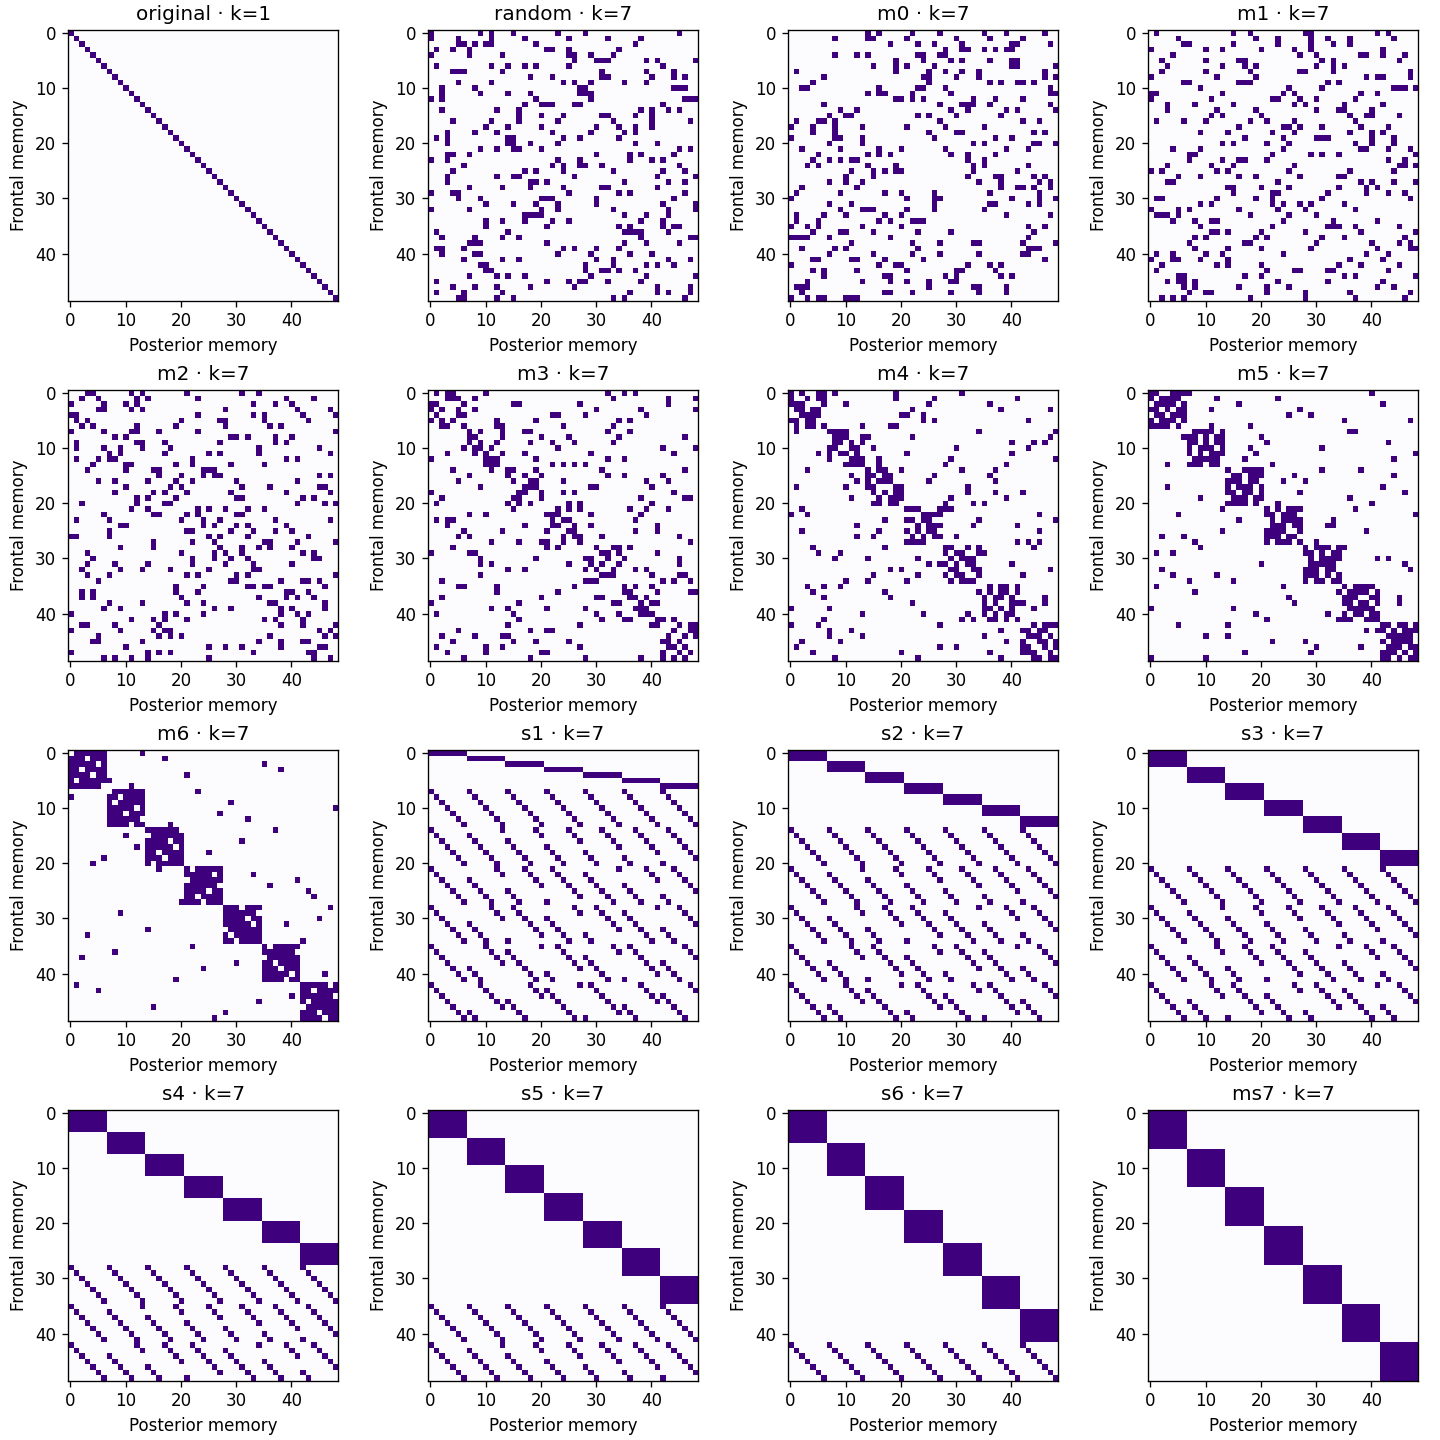

In [2]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12), constrained_layout=True)
for axis, item in zip(axes.flat, manifest['topologies']):
    axis.imshow(matrices[item['id']], interpolation='nearest', cmap='Purples', vmin=0, vmax=1)
    axis.set_title(f"{item['id']} · k={item['degree']}")
    axis.set_xlabel('Posterior memory')
    axis.set_ylabel('Frontal memory')
plt.show()


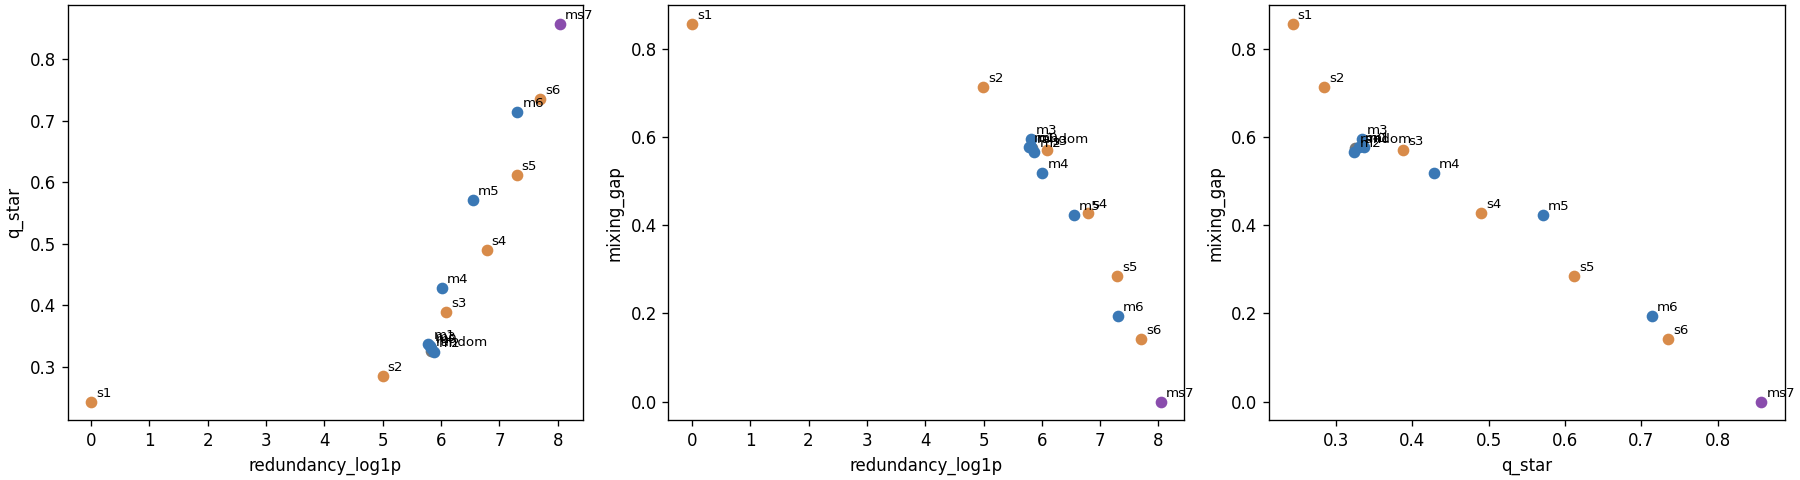

In [3]:
many = metrics[metrics['degree'] == 7]
colors = {'modular': '#3a78b5', 'shared-target': '#d88b4a', 'random': '#777777', 'endpoint': '#8a4dad'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for axis, (x, y) in zip(axes, [('redundancy_log1p', 'q_star'), ('redundancy_log1p', 'mixing_gap'), ('q_star', 'mixing_gap')]):
    for _, row in many.iterrows():
        axis.scatter(row[x], row[y], color=colors[row['family']])
        axis.annotate(row['topology'], (row[x], row[y]), xytext=(3, 3), textcoords='offset points', fontsize=8)
    axis.set(xlabel=x, ylabel=y)
plt.show()
